# Nexova Sales Forecast — EDA and Model Selection

Before we pass our data into a machine learning model, we explore and clean it
so it is understandable and safe to use. That process is called
**Exploratory Data Analysis (EDA)**.

This notebook follows the same simple flow as a standard Jupyter EDA guide:
import libraries → load data → inspect → prepare → visualize → train models → conclude.

**Business goal:** choose a modeling style for monthly consolidated revenue
(seasonal-naive vs Holt-Winters vs Ridge vs Random Forest) that Laura can trust for budget planning.


## What is Exploratory Data Analysis?

EDA means looking at the data first — tables, summaries, and charts — to learn:
- what columns mean
- whether anything is missing or broken
- what patterns repeat (for Nexova: August dips, Jan–Feb rises, slow growth)

We do EDA **before** picking a complex model, so the model choice matches the real pattern.


## Getting started with EDA

We use **pandas** (tables), **numpy** (numbers), **matplotlib** / **seaborn** (charts),
and shared helpers from `sales_forecast.py` so training rules stay consistent.


### Step-1: Import the Required libraries


In [37]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# Repo root (works if kernel starts in repo root or notebooks/)
cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "data" / "raw" / "nexova_sales.csv").exists() else cwd.parent
CSV_PATH = ROOT / "data" / "raw" / "nexova_sales.csv"

sys.path.insert(0, str(ROOT / "services" / "api"))
from domain import sales_forecast as sf

print("CSV path:", CSV_PATH)
print("CSV exists:", CSV_PATH.exists())


CSV path: D:\CodingProjects\company-project-ft-ai-1\data\raw\nexova_sales.csv
CSV exists: True


### Step-2: Load the dataset

The dataset is Nexova’s monthly consolidated revenue file.
Each row is one month of company-wide totals.

**Data contains**

1. **month:** First day of the month (`YYYY-MM-01`)
2. **revenue_usd:** Total revenue for the month (this is what we predict)
3. **active_contracts:** Count of active contracts that month
4. **avg_contract_value_usd:** Average contract value that month
5. **business_line:** Should be `consolidated` for the main model


In [38]:
sales_df = pd.read_csv(CSV_PATH)
sales_df["month"] = pd.to_datetime(sales_df["month"])
sales_df.head(5)


,month,revenue_usd,active_contracts,avg_contract_value_usd,business_line
0,2016-01-01,787980.89,218,3620.01,consolidated
1,2016-02-01,775834.31,205,3778.57,consolidated
2,2016-03-01,682431.41,165,4141.36,consolidated
3,2016-04-01,692811.97,189,3669.55,consolidated
4,2016-05-01,661461.45,183,3623.84,consolidated


### Step-3: Data Analysis On Nexova Sales Dataset

Get familiar with the shape, types, and basic stats. The main checks are:

- Head and Tail
- Shape
- Info / dtypes
- Describe
- Duplicates


#### Head and Tail


In [39]:
# First 5 records
print(sales_df.head(5))


       month  revenue_usd  active_contracts  avg_contract_value_usd  \
0 2016-01-01    787980.89               218                 3620.01   
1 2016-02-01    775834.31               205                 3778.57   
2 2016-03-01    682431.41               165                 4141.36   
3 2016-04-01    692811.97               189                 3669.55   
4 2016-05-01    661461.45               183                 3623.84   

  business_line  
0  consolidated  
1  consolidated  
2  consolidated  
3  consolidated  
4  consolidated  


In [40]:
# Last 5 records
print(sales_df.tail(5))


         month  revenue_usd  active_contracts  avg_contract_value_usd  \
115 2025-08-01    819255.69               219                 3748.66   
116 2025-09-01    982247.56               237                 4140.17   
117 2025-10-01    947235.96               256                 3695.91   
118 2025-11-01   1010975.62               266                 3796.97   
119 2025-12-01    982197.36               240                 4095.51   

    business_line  
115  consolidated  
116  consolidated  
117  consolidated  
118  consolidated  
119  consolidated  


#### Shape, info, and duplicates


In [41]:
# Rows and columns
sales_df.shape


(120, 5)

In [42]:
# Column types and non-null counts
sales_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   month                   120 non-null    datetime64[us]
 1   revenue_usd             120 non-null    float64       
 2   active_contracts        120 non-null    int64         
 3   avg_contract_value_usd  120 non-null    float64       
 4   business_line           120 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 4.8 KB


In [43]:
# Duplicate rows (should be 0)
sales_df.duplicated().sum()


np.int64(0)

In [44]:
# Numeric summary (mean, min, max, etc.)
sales_df.describe()


,month,revenue_usd,active_contracts,avg_contract_value_usd
count,120,1.200000e+02,120.000000,120.000000
mean,2020-12-15 18:00:00,8.194127e+05,205.816667,3989.147750
min,2016-01-01 00:00:00,5.233410e+05,130.000000,3605.200000
25%,2018-06-23 12:00:00,7.342144e+05,182.500000,3784.612500
50%,2020-12-16 12:00:00,8.101438e+05,203.500000,4010.840000
75%,2023-06-08 12:00:00,9.123292e+05,227.500000,4162.565000
max,2025-12-01 00:00:00,1.145989e+06,294.000000,4396.340000
std,NaN,1.253016e+05,31.732332,227.593129


**What to notice:** we expect **120 rows** (10 years × 12 months), no duplicates,
and `revenue_usd` always positive. If shape or duplicates look wrong, stop and fix
the file before modeling.


### Step-4: Data Preparation

Clean and organize the data so it is safe for forecasting:

- Check nulls
- Validate business rules (complete months, consolidated only)
- Split into train (2016–2023) and test (2024–2025)
- Build leakage-safe features (no peeking at future revenue)


In [45]:
# Missing values per column
sales_df.isnull().sum()


month                     0
revenue_usd               0
active_contracts          0
avg_contract_value_usd    0
business_line             0
dtype: int64

In [46]:
# Official validation + chronological 8-year / 2-year split
df = sf.validate_sales_dataset(sales_df)
train, test = sf.split_train_test(df)

print("Validated rows:", len(df))
print("Train rows:", len(train), "| Test rows:", len(test))
print("Train range:", train["month"].min().date(), "->", train["month"].max().date())
print("Test range:", test["month"].min().date(), "->", test["month"].max().date())
print("Business lines:", df["business_line"].unique().tolist())


Validated rows: 120
Train rows: 96 | Test rows: 24
Train range: 2016-01-01 -> 2023-12-01
Test range: 2024-01-01 -> 2025-12-01
Business lines: ['consolidated']


In [47]:
# Feature matrix for training (calendar + lags + rolling means)
# Early months may drop because lags need history — that is normal
x_train, y_train, featured_train = sf.training_matrix(train)

print("Feature columns:", list(x_train.columns))
print("Train matrix shape:", x_train.shape)
x_train.head(6)


Feature columns: ['time_index', 'month_sin', 'month_cos', 'revenue_lag_1', 'revenue_lag_12', 'revenue_rolling_mean_3', 'revenue_rolling_mean_12']
Train matrix shape: (84, 7)


,time_index,month_sin,month_cos,revenue_lag_1,revenue_lag_12,revenue_rolling_mean_3,revenue_rolling_mean_12
0,12.0,0.000000,1.000000e+00,656016.70,787980.89,676788.893333,673772.393333
1,13.0,0.500000,8.660254e-01,854473.93,775834.31,732515.083333,679313.480000
2,14.0,0.866025,5.000000e-01,823641.27,682431.41,778043.966667,683297.393333
3,15.0,1.000000,6.123234e-17,738121.26,692811.97,805412.153333,687938.214167
4,16.0,0.866025,-5.000000e-01,735241.82,661461.45,765668.116667,691474.035000
5,17.0,0.500000,-8.660254e-01,715917.60,647909.20,729760.226667,696012.047500


After validation, the dataset should be clean (no nulls, 96/24 split).
Features encode **trend**, **seasonality**, and **recent history** without using
same-month contract columns (those would leak information).


### Step-5: Exploratory Data Analysis (Data Visualisation)

Charts help us see patterns that tables hide. Three common views:

- **Univariate:** one variable at a time (revenue over time, month-of-year averages)
- **Bivariate:** relationship between two variables (revenue vs contracts)
- **Multivariate:** many variables together (correlation heatmap)

**Why this matters for model choice**
- Clear August dips + Jan/Feb peaks → a seasonal baseline will be strong
- Smooth growth + calendar waves → a simple linear model (Ridge) may be enough
- Extra bends a straight line cannot catch → Random Forest may help


#### Line chart (univariate — revenue over time)

Look for overall growth and the red dashed train/test split line.


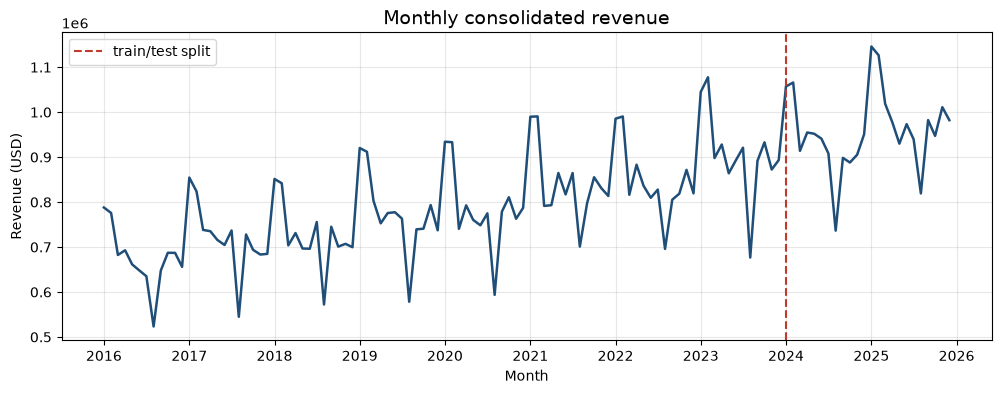

In [48]:
plt.figure(figsize=(12, 4))
plt.title("Monthly consolidated revenue", fontsize=14)
plt.plot(df["month"], df["revenue_usd"], color="#1f4e79", lw=1.8)
plt.axvline(sf.SPLIT_CUTOFF, color="#c0392b", ls="--", label="train/test split")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### Bar chart (univariate — average month-of-year pattern)

Compare each calendar month to the overall average.
August should be clearly lower; January–February should be higher.


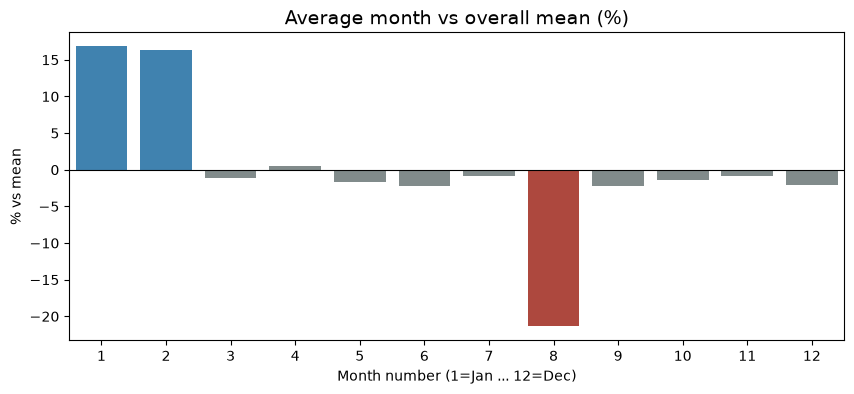

month_num
1     16.81
2     16.39
3     -1.08
4      0.57
5     -1.67
6     -2.26
7     -0.82
8    -21.39
9     -2.20
10    -1.44
11    -0.84
12    -2.07
Name: revenue_usd, dtype: float64


In [49]:
work = df.copy()
work["month_num"] = work["month"].dt.month
work["year"] = work["month"].dt.year

month_profile = work.groupby("month_num")["revenue_usd"].mean()
overall_mean = work["revenue_usd"].mean()
vs_overall_pct = (month_profile / overall_mean - 1.0) * 100

colors = ["#c0392b" if m == 8 else "#2e86c1" if m in (1, 2) else "#7f8c8d" for m in vs_overall_pct.index]

plt.figure(figsize=(10, 4))
plt.title("Average month vs overall mean (%)", fontsize=14)
sns.barplot(x=vs_overall_pct.index, y=vs_overall_pct.values, palette=colors)
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("Month number (1=Jan ... 12=Dec)")
plt.ylabel("% vs mean")
plt.show()

print(vs_overall_pct.round(2))


#### Year-over-year growth (univariate summary)

Positive growth with alternating strong/weak years supports a mild trend feature.


In [50]:
yearly = work.groupby("year", as_index=False)["revenue_usd"].sum()
yearly["yoy_growth_pct"] = yearly["revenue_usd"].pct_change() * 100
yearly.round(2)


,year,revenue_usd,yoy_growth_pct
0,2016,8085268.72,NaN
1,2017,8643839.91,6.91
2,2018,8702041.09,0.67
3,2019,9293138.53,6.79
4,2020,9417553.34,1.34
5,2021,10109350.62,7.35
6,2022,10159753.31,0.50
7,2023,10893866.04,7.23
8,2024,11171763.36,2.55
9,2025,11852954.58,6.10


#### Scatter plot (bivariate — revenue vs active contracts)

If these move together tightly, contracts are related to revenue — but we still
avoid using *same-month* contracts as a forecast input (leakage risk).


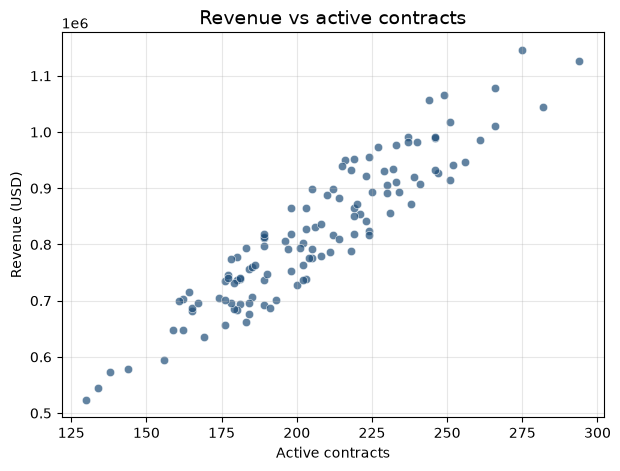

In [51]:
plt.figure(figsize=(7, 5))
plt.title("Revenue vs active contracts", fontsize=14)
sns.scatterplot(data=df, x="active_contracts", y="revenue_usd", color="#1f4e79", alpha=0.7)
plt.xlabel("Active contracts")
plt.ylabel("Revenue (USD)")
plt.grid(True, alpha=0.3)
plt.show()


#### Heatmap (multivariate — correlation matrix)

Values near **+1** move together; near **-1** move opposite; near **0** are weakly related.


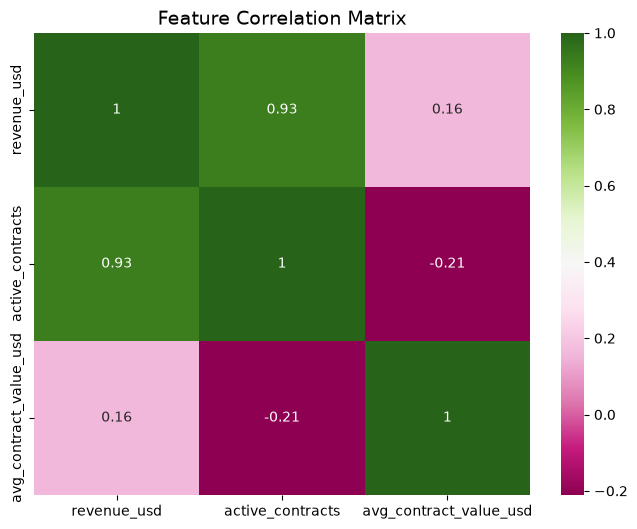

In [52]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[["revenue_usd", "active_contracts", "avg_contract_value_usd"]].corr(),
    annot=True,
    cmap="PiYG",
)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.show()


**EDA takeaway for modeling:** Nexova revenue shows strong calendar seasonality and
steady growth. That favors a **traditional seasonal time-series model** (Holt-Winters)
and means seasonal-naive is a tough baseline. Prefer a more complex ML model only if
it clearly beats those simpler options on the holdout years.


### Step-6: Model Building

Model building creates predictors we can compare fairly on the same test years.

**Candidates**

1. **Seasonal-naive:** copy last training year’s month pattern (minimum useful bar)
2. **Holt-Winters (traditional time-series):** classic exponential smoothing with
   trend + 12-month seasonality — no engineered lag features required
3. **Ridge:** simple linear style using calendar + lag features
4. **Random Forest:** flexible tree ensemble (current shipped candidate)

**Decision rules (plain English)**
1. Must beat seasonal-naive **RMSE** on 2024–2025 (deploy gate)
2. Prefer higher **normalized Gini** (ranks strong vs weak months well)
3. Report PSI / K² as health checks
4. If a traditional time-series or Ridge ≈ Random Forest, prefer the simpler model


In [53]:
# Quick look at the target we will predict on the test years
print("Test months:", len(test))
print(test[["month", "revenue_usd"]].head())
print("\nFeature summary used for ML models:")
print(x_train.describe().T[["mean", "std", "min", "max"]].round(3))


Test months: 24
       month  revenue_usd
0 2024-01-01   1057106.38
1 2024-02-01   1065896.32
2 2024-03-01    913922.70
3 2024-04-01    954748.46
4 2024-05-01    951994.39

Feature summary used for ML models:
                               mean         std         min          max
time_index                   53.500      24.393      12.000       95.000
month_sin                     0.000       0.711      -1.000        1.000
month_cos                    -0.000       0.711      -1.000        1.000
revenue_lag_1            797407.737  103848.637  544864.910  1077508.590
revenue_lag_12           766796.970   97357.964  523341.040   990511.660
revenue_rolling_mean_3   794961.691   80996.647  655571.480  1006809.913
revenue_rolling_mean_12  782676.512   61963.347  673772.393   901662.753


### Step-7: Train the models

We train on 2016–2023 only, then forecast 2024–2025.

- **Holt-Winters** forecasts the next 24 months directly from the monthly series
- **Ridge / Random Forest** use recursive multi-step forecasting with features


In [54]:
from sklearn.linear_model import Ridge
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Baseline: repeat last train-year seasonal cycle
naive_pred = sf.seasonal_naive_forecast(train, test)

# Traditional time-series: Holt-Winters additive trend + additive monthly seasonality
# (classic "ETS" style model for seasonal monthly revenue)
train_ts = (
    train.set_index("month")["revenue_usd"]
    .astype(float)
    .asfreq("MS")
)
hw_model = ExponentialSmoothing(
    train_ts,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
)
hw_fit = hw_model.fit(optimized=True)
hw_pred = np.asarray(hw_fit.forecast(len(test)), dtype=float)

# Random Forest + uncertainty width from chronological within-train folds
oof = sf.chronological_oof_predictions(x_train, y_train)
oof_mask = ~np.isnan(oof)
conformal_q = sf.conformal_residual_quantile(
    y_train.to_numpy(dtype=float)[oof_mask],
    oof[oof_mask],
)

rf = sf.fit_final_model(x_train, y_train)
_, rf_pred_list = sf.recursive_forecast(rf, train, test["month"])
rf_pred = np.asarray(rf_pred_list, dtype=float)

# Ridge: simple linear challenger on engineered features
ridge = Ridge(alpha=10.0, random_state=sf.RANDOM_STATE)
ridge.fit(x_train, y_train)
_, ridge_pred_list = sf.recursive_forecast(ridge, train, test["month"])
ridge_pred = np.asarray(ridge_pred_list, dtype=float)

y_true = test["revenue_usd"].to_numpy(dtype=float)
candidates = {
    "seasonal_naive": naive_pred,
    "holt_winters": hw_pred,
    "ridge": ridge_pred,
    "random_forest": rf_pred,
}

print("Train features shape:", x_train.shape)
print("Test predictions:", {k: len(v) for k, v in candidates.items()})
print("RF conformal width (USD):", round(conformal_q, 2))
print("Holt-Winters AIC:", round(float(hw_fit.aic), 2))


Train features shape: (84, 7)
Test predictions: {'seasonal_naive': 24, 'holt_winters': 24, 'ridge': 24, 'random_forest': 24}
RF conformal width (USD): 103137.96
Holt-Winters AIC: 1985.02


#### Scorecard (compare models)

Focus on:
- **rmse_usd** → lower is better; must beat seasonal-naive
- **normalized_gini** → higher is better for ranking months
- **beats_naive** → True means the model cleared the business gate


In [55]:
oof_valid = oof[~np.isnan(oof)]

rows = []
for name, pred in candidates.items():
    point = sf.compute_point_metrics(y_true, pred)
    k2 = sf.compute_k2(y_true - pred)
    psi = sf.population_stability_index(oof_valid, pred)
    rows.append(
        {
            "model": name,
            "rmse_usd": point["rmse_usd"],
            "nrmse_percent": point["nrmse_percent"],
            "normalized_gini": point["normalized_gini"],
            "r2": point["r2"],
            "psi": psi,
            "psi_label": sf.interpret_psi(psi),
            "k2_pvalue": k2["k2_pvalue"],
        }
    )

scoreboard = pd.DataFrame(rows).sort_values("rmse_usd")
naive_rmse = float(scoreboard.loc[scoreboard["model"] == "seasonal_naive", "rmse_usd"].iloc[0])
scoreboard["beats_naive"] = scoreboard["rmse_usd"] < naive_rmse
scoreboard.round(4)


,model,rmse_usd,nrmse_percent,normalized_gini,r2,psi,psi_label,k2_pvalue,beats_naive
1,holt_winters,34493.7055,3.5955,0.8997,0.8405,9.8348,significant shift,0.0093,True
2,ridge,36088.5280,3.7617,0.8337,0.8254,9.7049,significant shift,0.8243,True
3,random_forest,55499.3236,5.7850,0.8225,0.5871,9.6645,significant shift,0.2372,True
0,seasonal_naive,70096.8905,7.3066,0.6756,0.3413,9.2958,significant shift,0.8867,False


#### Prediction chart (holdout years)

Compare each model line to actual revenue. Check August dips and early-year peaks.


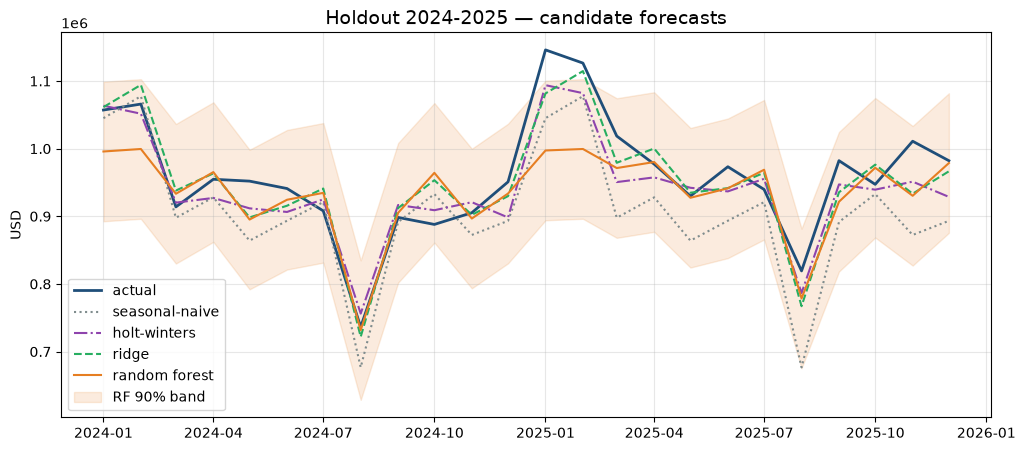

RF interval coverage: 0.917


In [56]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test["month"], y_true, label="actual", color="#1f4e79", lw=2)
ax.plot(test["month"], candidates["seasonal_naive"], label="seasonal-naive", ls=":", color="#7f8c8d")
ax.plot(test["month"], candidates["holt_winters"], label="holt-winters", ls="-.", color="#8e44ad")
ax.plot(test["month"], candidates["ridge"], label="ridge", ls="--", color="#27ae60")
ax.plot(test["month"], candidates["random_forest"], label="random forest", color="#e67e22")

lower, upper = sf.apply_prediction_interval(rf_pred, conformal_q)
ax.fill_between(test["month"], lower, upper, color="#e67e22", alpha=0.15, label="RF 90% band")

ax.set_title("Holdout 2024-2025 — candidate forecasts", fontsize=14)
ax.set_ylabel("USD")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.show()

print("RF interval coverage:", round(sf.interval_coverage(y_true, lower, upper), 3))


### Conclusion

Use the scoreboard + chart to pick a modeling style:

| Result | What it means |
|--------|----------------|
| Nothing beats seasonal-naive | Do not recommend a dashboard on ML alone yet |
| Holt-Winters wins or ties | Prefer the traditional seasonal time-series style |
| Ridge wins or ties RF | Prefer the simpler linear feature-based style |
| RF clearly better on RMSE and Gini | Nonlinear ensemble is justified |
| All ML / TS options fail the gate | Improve features/process before trying XGBoost |

Fill the decision cell below for Laura / Marcos.


In [57]:
DECISION = {
    "chosen_model": None,  # "holt_winters" | "ridge" | "random_forest" | "seasonal_naive" | "xgboost"
    "beats_seasonal_naive": None,  # True / False
    "recommend_dashboard_on_model_alone": None,  # True only if gate passed
    "rationale": "",  # 2-4 plain-English sentences
}

DECISION


{'chosen_model': None,
 'beats_seasonal_naive': None,
 'recommend_dashboard_on_model_alone': None,
 'rationale': ''}